# Statistical analysis of abalones

The data to be analyzed concerns snails called *abalones*. The dataset comprises 9 variables (attributes, features) of these snails and contains 4177 observations. One of the variables is qualitative (sex), whereas the others are quantitative.

---

### Preparing dataset
Importing necessery packages and modules.

In [1]:
from itertools import combinations

from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

Importing dataset and set proper header for each feature.

In [2]:

headers = [
    "Sex",
    "Length",
    "Diameter",
    "Height",
    "Whole weight",
    "Shucked weight",
    "Viscera weight",
    "Shell weight",
    "Rings",
]

# Param 'names' defaults to the first row as data
df = (
    pd.read_csv("data.csv", names=headers)
    .replace(['M', 'I', 'F'], ['Male', 'Infant', 'Female'])
)

---
#### Data processing

Creating a table of the distribution of the qualitative variable.

In [3]:
quali_distrib = df["Sex"].value_counts()
quali_distrib.index = ["Male", "Infant", "Female"]

distrib_table = quali_distrib.to_frame()

total_population = sum(quali_distrib)
procengate = round(distrib_table * 100 / total_population, 2)
procengate

distrib_table.insert(1, "%", procengate)

display(Markdown("Table 1. Sex distribution."))
distrib_table


Table 1. Sex distribution.

,count,%
Male,1528,36.58
Infant,1342,32.13
Female,1307,31.29


In [4]:
described = df.describe().drop('count').T

display(Markdown("Table 2. Summary statistics for the quantitative variables."))
described


Table 2. Summary statistics for the quantitative variables.

,mean,std,min,25%,50%,75%,max
Length,0.523992,0.120093,0.0750,0.4500,0.5450,0.615,0.8150
Diameter,0.407881,0.099240,0.0550,0.3500,0.4250,0.480,0.6500
Height,0.139516,0.041827,0.0000,0.1150,0.1400,0.165,1.1300
Whole weight,0.828742,0.490389,0.0020,0.4415,0.7995,1.153,2.8255
Shucked weight,0.359367,0.221963,0.0010,0.1860,0.3360,0.502,1.4880
Viscera weight,0.180594,0.109614,0.0005,0.0935,0.1710,0.253,0.7600
Shell weight,0.238831,0.139203,0.0015,0.1300,0.2340,0.329,1.0050
Rings,9.933684,3.224169,1.0000,8.0000,9.0000,11.000,29.0000


---
#### Data visualization

Bar chart of the counts of occurrences of each category for the qualitative variable in the dataset.

Text(0.5, 1.0, 'The counts of occurrences of each category')

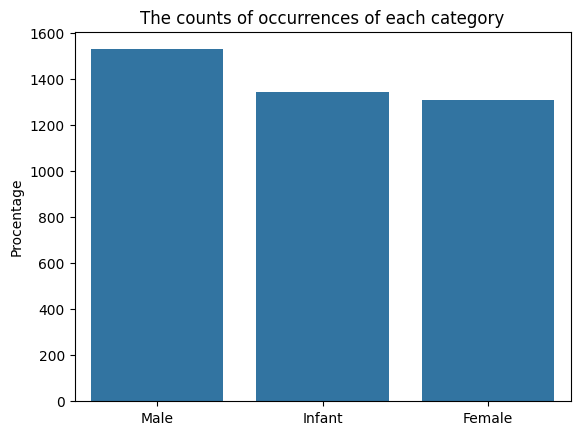

In [5]:
bar_plot = sns.barplot(quali_distrib)
bar_plot.set(ylabel='Procentage')
bar_plot.set_title('The counts of occurrences of each category')

Histogram of each quantitative variable in the dataset

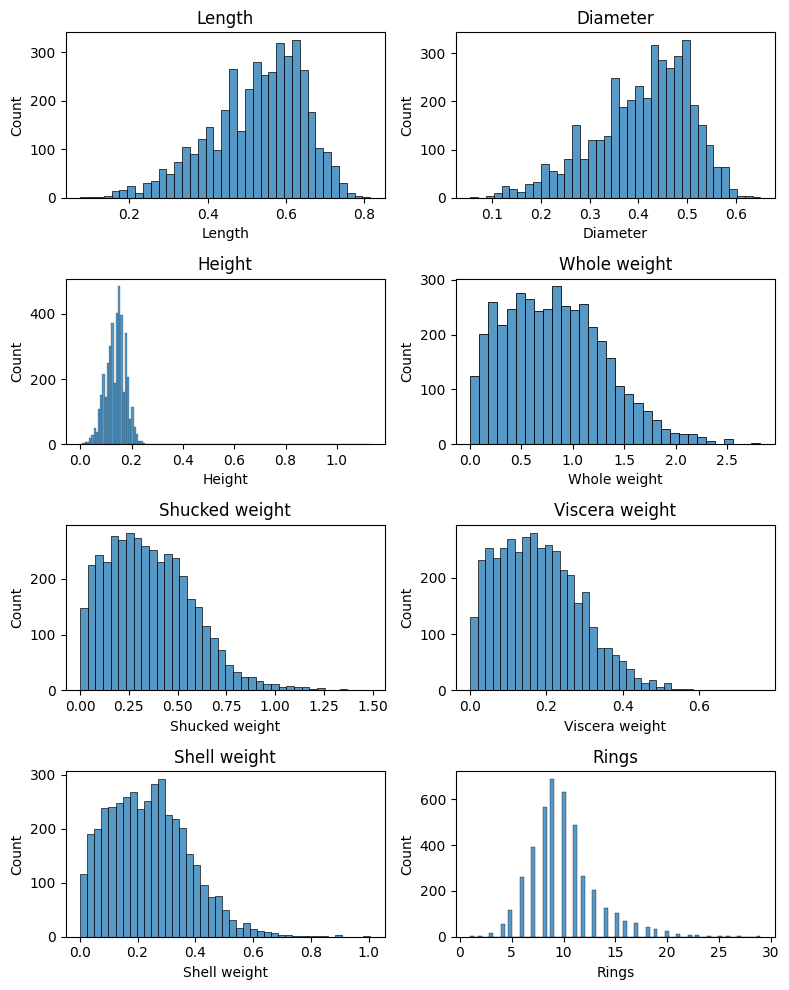

In [6]:
quantitative_cols = df.drop(columns='Sex').columns

fig, axes = plt.subplots(4, 2, figsize=(8, 10))
axes = axes.flat

for ax, col_name in zip(axes, quantitative_cols):
    sns.histplot(data=df, x=col_name, ax=ax)
    ax.set_title(col_name)
plt.tight_layout()

Scatter plot for each pair of the quantitative variables

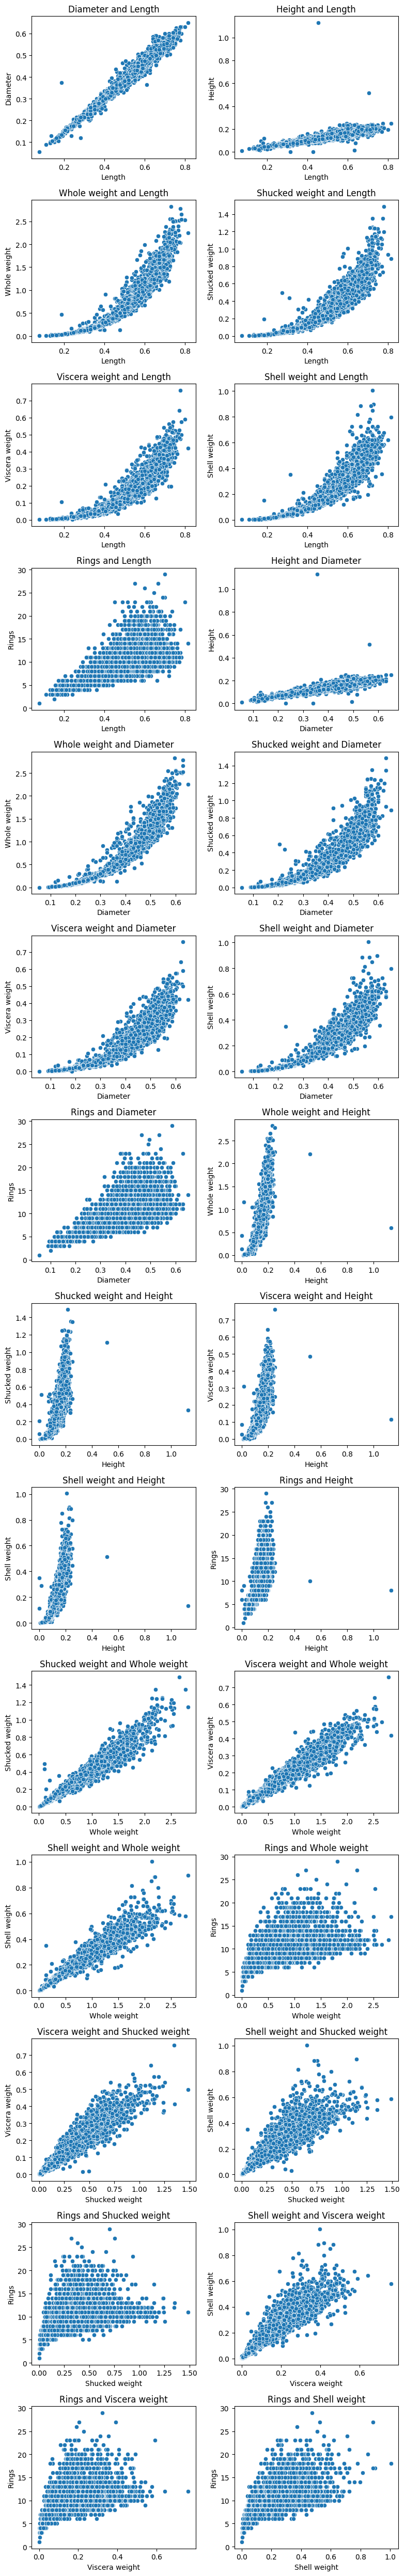

In [7]:
col_pairs = combinations(df.drop(columns='Sex').columns, 2)

fig, axes = plt.subplots(14, 2, figsize=(8,50)) 
axes = axes.flat

for ax, (col1, col2) in zip(axes, col_pairs):
    sns.scatterplot(x=df[col1], y=df[col2], ax=ax)
    ax.set_title(f"{col2} and {col1}")
plt.tight_layout()


Table representing a linear correlation matrix

In [8]:
corr = df.corr(numeric_only=True)
corr


,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
Length,1.000000,0.986812,0.827554,0.925261,0.897914,0.903018,0.897706,0.556720
Diameter,0.986812,1.000000,0.833684,0.925452,0.893162,0.899724,0.905330,0.574660
Height,0.827554,0.833684,1.000000,0.819221,0.774972,0.798319,0.817338,0.557467
Whole weight,0.925261,0.925452,0.819221,1.000000,0.969405,0.966375,0.955355,0.540390
Shucked weight,0.897914,0.893162,0.774972,0.969405,1.000000,0.931961,0.882617,0.420884
Viscera weight,0.903018,0.899724,0.798319,0.966375,0.931961,1.000000,0.907656,0.503819
Shell weight,0.897706,0.905330,0.817338,0.955355,0.882617,0.907656,1.000000,0.627574
Rings,0.556720,0.574660,0.557467,0.540390,0.420884,0.503819,0.627574,1.000000


Heatmap representing a linear correlation matrix of all quantitative variables 

(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5]),
 [Text(0.5, 1, 'Length'),
  Text(1.5, 1, 'Diameter'),
  Text(2.5, 1, 'Height'),
  Text(3.5, 1, 'Whole weight'),
  Text(4.5, 1, 'Shucked weight'),
  Text(5.5, 1, 'Viscera weight'),
  Text(6.5, 1, 'Shell weight'),
  Text(7.5, 1, 'Rings')])

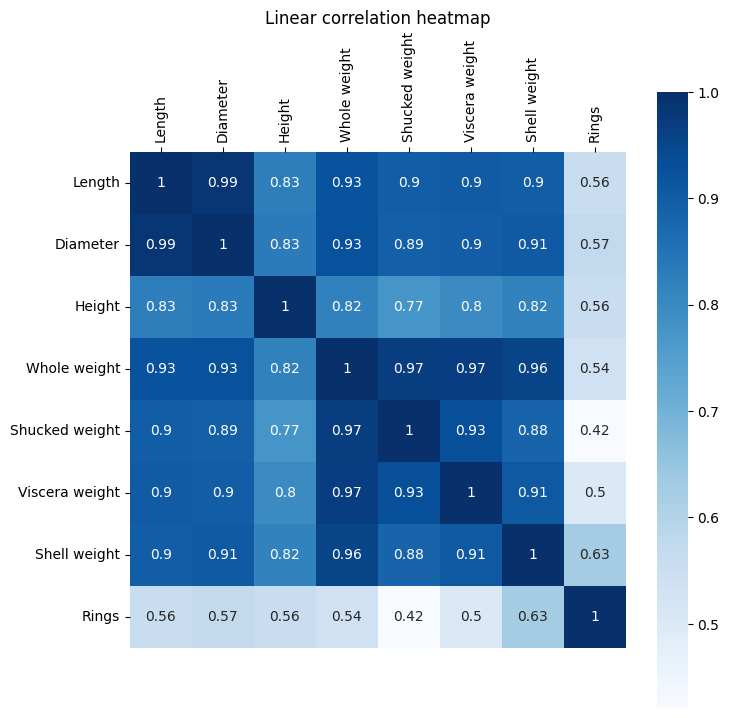

In [9]:
fig, ax = plt.subplots(figsize=(8,8)) 

sns.heatmap(corr, square=True,  cmap="Blues", annot=True, ax=ax)
ax.xaxis.tick_top()
ax.set_title(f"Linear correlation heatmap")
plt.xticks(rotation=90)


Linear regression plot with the two quantitative variables that are most strongly linearly correlated.

Text(0.5, 1.0, 'Linear regression plot: Length vs Diameter')

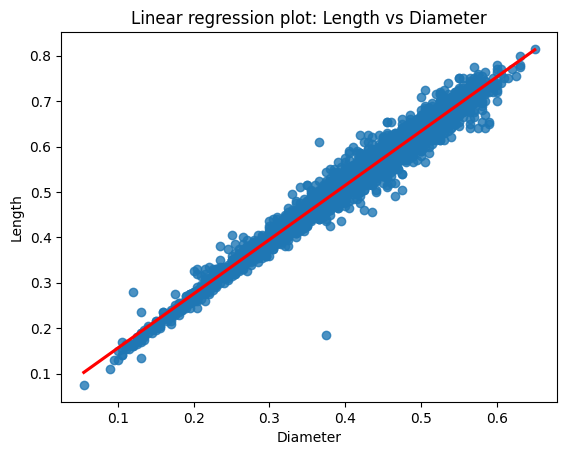

In [10]:
ax = sns.regplot(data=df, x="Diameter", y="Length", line_kws={"color": "red"})

plt.title("Linear regression plot: Length vs Diameter")

---
### Table with summary statistics for the quantitative variables in the dataset split by the categories of the qualitative variable

In [11]:
grouped = (
    df.groupby('Sex')
    .describe()
    .stack(level=0, future_stack=True)
    .swaplevel()
    .sort_index()
    .drop(columns=['count'])
)

grouped.index.names = ['Feature', 'Sex']

grouped

mean       std     min       25%       50%  \
Feature        Sex                                                       
Diameter       Female   0.454732  0.070954  0.1950  0.410000   0.46500   
               Infant   0.326494  0.088109  0.0550  0.270000   0.33500   
               Male     0.439287  0.084398  0.1100  0.395000   0.45500   
Height         Female   0.158011  0.039984  0.0150  0.140000   0.16000   
               Infant   0.107996  0.031995  0.0000  0.085000   0.11000   
               Male     0.151381  0.034804  0.0250  0.130000   0.15500   
Length         Female   0.579093  0.086160  0.2750  0.525000   0.59000   
               Infant   0.427746  0.108858  0.0750  0.360000   0.43500   
               Male     0.561391  0.102697  0.1550  0.505000   0.58000   
Rings          Female  11.129304  3.104256  5.0000  9.000000  10.00000   
               Infant   7.890462  2.511554  1.0000  6.000000   8.00000   
               Male    10.705497  3.026349  3.0000  9.000000  10.00000   
Shell weight   Female   0.302010  0.125649  0.0250  0.213250   0.29500   
               Infant   0.128182  0.084927  0.0015  0.064125   0.11300   
               Male     0.281969  0.130834  0.0050  0.190000   0.27600   
Shucked weight Female   0.446188  0.198663  0.0310  0.295000   0.44050   
               Infant   0.191035  0.128405  0.0010  0.090000   0.16975   
               Male     0.432946  0.223000  0.0065  0.276375   0.42175   
Viscera weight Female   0.230689  0.097617  0.0210  0.159000   0.22400   
               Infant   0.092010  0.062536  0.0005  0.042500   0.08050   
               Male     0.215545  0.104919  0.0030  0.145875   0.21000   
Whole weight   Female   1.046532  0.430316  0.0800  0.730000   1.03850   
               Infant   0.431363  0.286275  0.0020  0.205500   0.38400   
               Male     0.991459  0.470581  0.0155  0.671625   0.97575   

                             75%      max  
Feature        Sex                         
Diameter       Female   0.505000   0.6500  
               Infant   0.390000   0.5500  
               Male     0.500000   0.6300  
Height         Female   0.175000   1.1300  
               Infant   0.130000   0.2200  
               Male     0.175000   0.5150  
Length         Female   0.640000   0.8150  
               Infant   0.510000   0.7250  
               Male     0.630000   0.7800  
Rings          Female  12.000000  29.0000  
               Infant   9.000000  21.0000  
               Male    12.000000  27.0000  
Shell weight   Female   0.375000   1.0050  
               Infant   0.178500   0.6550  
               Male     0.355500   0.8970  
Shucked weight Female   0.573250   1.4880  
               Infant   0.270375   0.7735  
               Male     0.566000   1.3510  
Viscera weight Female   0.297250   0.5900  
               Infant   0.130000   0.4405  
               Male     0.278000   0.7600  
Whole weight   Female   1.320250   2.6570  
               Infant   0.599375   2.0495  
               Male     1.265625   2.8255

---

### A boxplot of each quantitative variable in the dataset, grouping every one of them by the qualitative variable

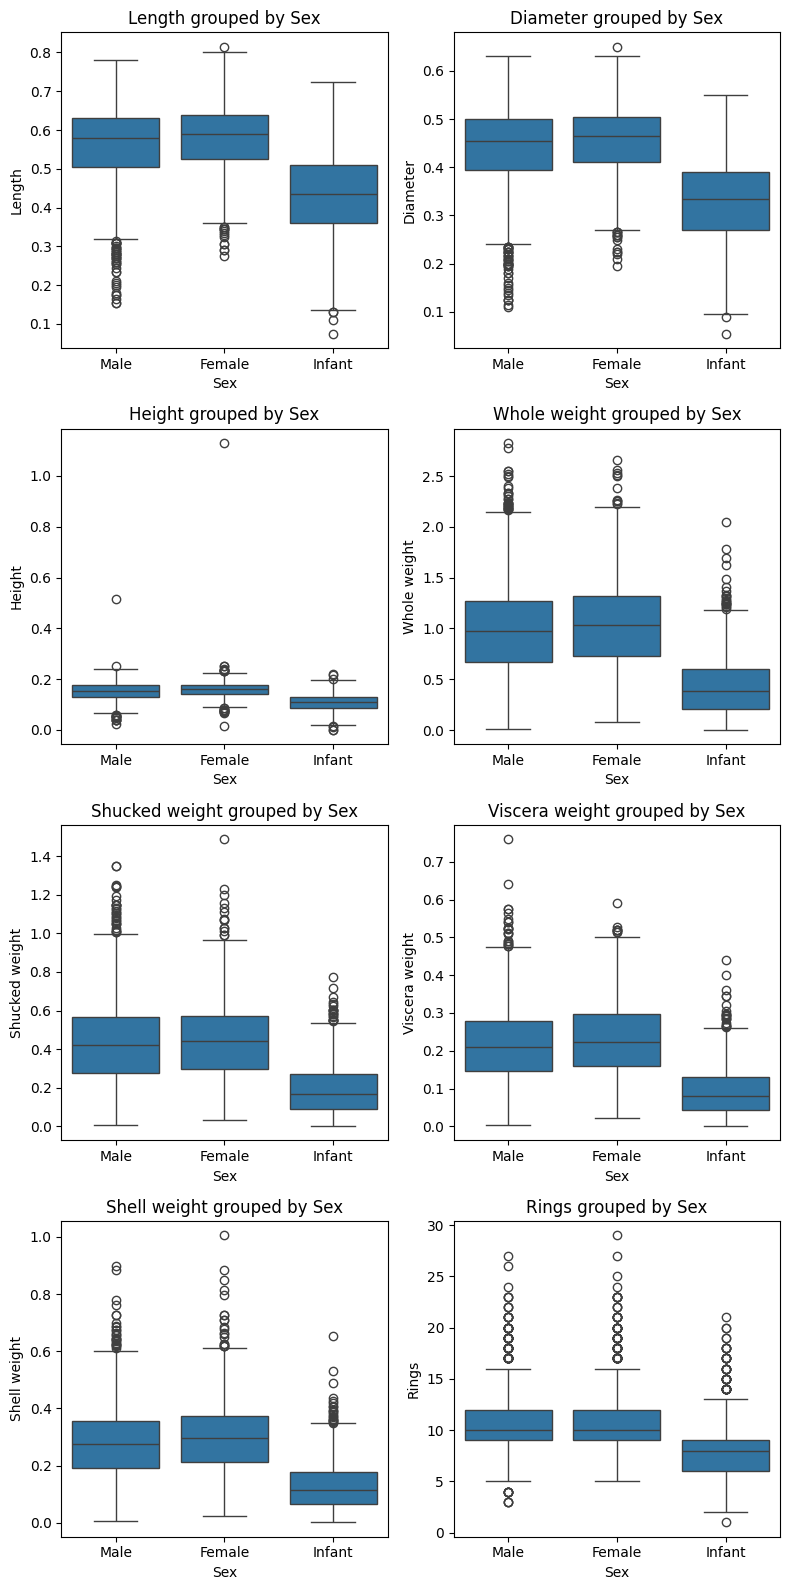

In [12]:
quantitative_features = df.drop(columns='Sex').columns

fig, axes = plt.subplots(4, 2, figsize=(8, 16))

axes = axes.flat

for ax, feature in zip(axes, quantitative_features):
    sns.boxplot(data=df, x='Sex', y=feature, ax=ax)    
    ax.set_title(f'{feature} grouped by Sex')

plt.tight_layout()
plt.show()